# Titanic Passengers

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Notebooks can be used to run shell commands (for testing purposes)
# In Linux: !ls -lrt
# In Windows: !dir

### Data loading

In [4]:
# Load the data into the dataframe and display the first rows
data = pd.read_csv("Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# You can inspect the table information, including column names and data types.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# You can also check the number of missing values in each column.
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### El número de pasajeros.

In [7]:
num_passengers = len(data)
num_passengers

891

In [8]:
# It can also be done using pandas.

num_passengers_pan = data.shape[0]
num_passengers_pan

891

### Number of survivors of the total

In [9]:
num_survivors = data["Survived"].sum()
num_survivors

342

In [10]:
# you can obtain this with the explicit way.
num_survivors_exp = (data["Survived"] == 1).sum()
num_survivors_exp

342

### Survival rate

In [11]:
porc_survivors = round(num_survivors/num_passengers*100,2)
porc_survivors

38.38

### Survival rate by sex

In [12]:
survival_by_sex = data.groupby("Sex")["Survived"].mean() * 100
survival_by_sex

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Sex'}, xlabel='Sex', ylabel='Percentage'>

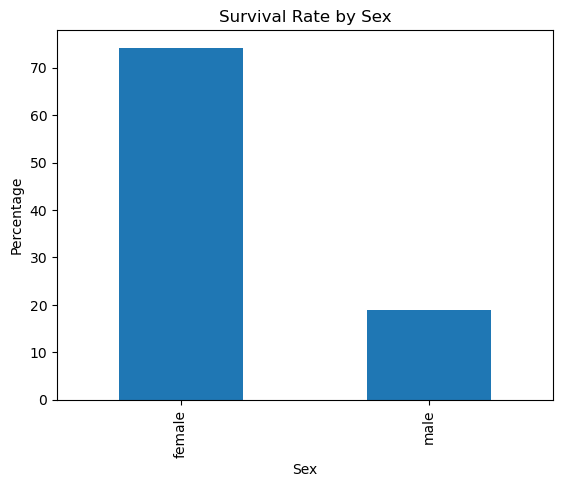

In [14]:
survival_by_sex.plot(kind="bar", title="Survival Rate by Sex", ylabel = "Percentage")

### Survival rate by passenger class

In [18]:
survival_by_class = data.groupby("Pclass")["Survived"].mean()*100
survival_by_class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival rate by class'}, xlabel='Pclass', ylabel='Percentage'>

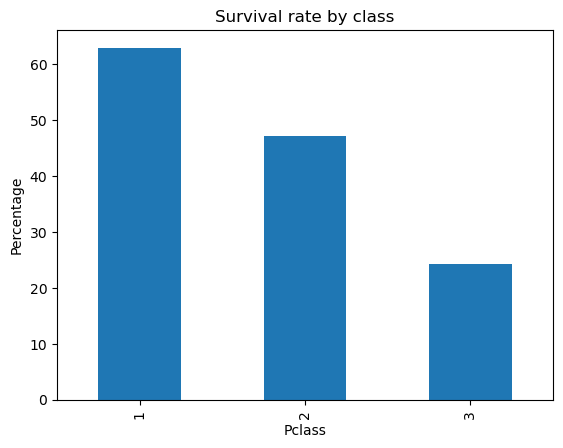

In [19]:
survival_by_class.plot (kind = "bar", title = "Survival rate by class", ylabel = "Percentage")

### Age analysis

In [34]:
age_mean =data["Age"].mean()
print(f"The mean age is {age_mean:.2f}")
age_median = data["Age"].median()
print(f"The median age is {age_median:.2f}")

The mean age is 29.70
The median age is 28.00


In [39]:
age_mean_survivors = data[data["Survived"] == 1]["Age"].mean()
print(f"The mean age of survivors is {age_mean_survivors:.2f}")
age_mean_no_survivors = data[data["Survived"] == 0]["Age"].mean()
print(f"The mean age of passengers who did not survive is {age_mean_no_survivors:.2f}")

The mean age of survivors is 28.34
The mean age of passengers who did not survive is 30.63


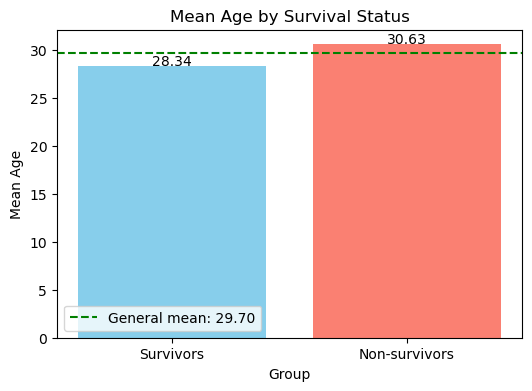

In [47]:
labels = ["Survivors", "Non-survivors"]
means = [age_mean_survivors, age_mean_no_survivors]


plt.figure(figsize=(6,4))
bars = plt.bar(labels, means, color=["skyblue", "salmon"])


plt.axhline(age_mean, color="green", linestyle="--", label=f'General mean: {age_mean:.2f}')

# Añadir valores encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}', ha="center", va = "center" )

# Etiquetas y título
plt.xlabel("Group")
plt.ylabel("Mean Age")
plt.title("Mean Age by Survival Status")
plt.legend()
plt.show()

### Conclusions
- Total passengers: 891
- Survivors: 342
- Survival rate: 38.38%
- Observation: women had a higher survival rate.
- Mean Age: 29.70
- Mean Age of survivors: 28.34
- Mean Age of non-survivors: 30.63
- Observation: The average age of survivors was lower than that of non-survivors.